## 01. Data Exploration and Exploratory Data Analysis

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import unicodedata
import string
import re
import spacy

df = pd.read_csv('../data/raw/ph_sms_dataset.csv')
df.sample(10)

,masked_celphone_number,hashed_cellphone_number,date,text,carrier,Target
722,+63985****255,562938c5-afdd-3dc9-94ad-8a7044159d55,2023-09-27 08:44:01.946,Join RichPH and become the king of the dynasty...,Smart/TNT,Spam
815,+63921****348,acc8aa36-7e71-3186-b7c5-8374adbf83df,2023-05-13 01:24:13.780,<<Content not supported.>>,Smart,Legitimate (ham)
80,+63951****823,068df9c4-d806-3918-bd18-8dca2856ac4f,2024-07-04 06:44:54.516,Ikaw ang maswerteng\nMakatanggap ng P555 na \n...,Smart,Smishing (scam)
308,Newbuy info,b16a96b5-9942-38d8-92b3-219f7979d223,2024-04-05 12:40:25.148,Limited! CI 100 get 400.\nEaster egg 55555 up ...,<unknown>,Spam
298,+63981****479,820548fe-4101-3114-a410-60b24d47e1c8,2024-04-06 18:32:35.729,Mga boss. Meron tayong libreng 100 piso na ipa...,Smart,Spam
715,+63909****627,9b638b42-1897-3b41-8802-83e0d1183148,2023-10-01 23:48:37.166,Gawin ang iyong unang deposito ng 177P sa 177B...,TNT,Spam
39,GLOBE,b4440a5b-996e-329b-9151-c0c600037802,2025-04-25 05:35:29.207,"GLOBE reminds you that your reward points (5,3...",<unknown>,Smishing (scam)
385,+63981****737,736052d4-5b17-3368-aa7d-e87c6b2e3af3,2024-03-23 20:32:22.948,"Log in to receive PHP108 free rewards, deposit...",Smart,Spam
435,+63981****221,4f6be7fa-79eb-3ae3-a887-adbc4bb7c2fc,2024-03-13 04:22:54.223,betslotsph.tv/3uMkv7 Doblehin ang saya at pana...,Smart,Spam
910,+63949****757,95c46321-f9af-3e3a-a709-096c4b00c8a3,2022-12-29 03:58:12.738,d! Claim the BARAHA B0NUS 2023P! Big events on...,Smart,Legitimate (ham)


In [70]:
df.shape

(1021, 6)

In [71]:
df.isna().sum()

masked_celphone_number     0
hashed_cellphone_number    0
date                       0
text                       0
carrier                    0
Target                     0
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   masked_celphone_number   1021 non-null   str  
 1   hashed_cellphone_number  1021 non-null   str  
 2   date                     1021 non-null   str  
 3   text                     1021 non-null   str  
 4   carrier                  1021 non-null   str  
 5   Target                   1021 non-null   str  
dtypes: str(6)
memory usage: 48.0 KB


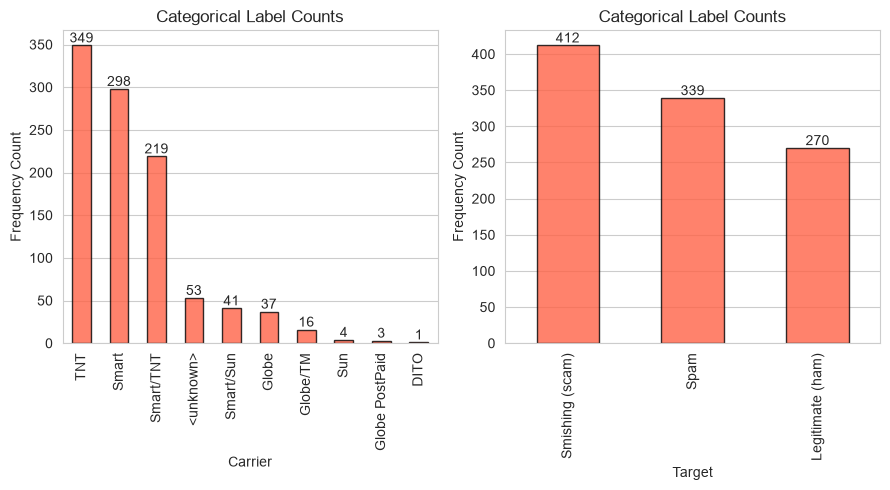

In [74]:
categoricals = ['carrier', 'Target']

fig, ax = plt.subplots(1, 2, figsize=(9, 5))

sns.set_style('whitegrid')
for i, cats in enumerate(categoricals):
    counts = df[cats].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', alpha=0.8, ax=ax[i], edgecolor='black', color='tomato')
    ax[i].set_ylabel('Frequency Count')
    ax[i].set_xlabel(f"{cats.title()}")
    ax[i].set_title('Categorical Label Counts')
    ax[i].bar_label(ax[i].containers[0])
    ax[i].grid(axis='x')
plt.tight_layout()


## Data Cleaning

In [75]:

def count_words(words: str) -> int:
    words = words.split()
    return len(words)

def transform(df: pd.DataFrame) -> pd.DataFrame:

    if df.empty:
        raise ValueError("The DataFrame is Empty.")

    data = df.copy()

    try:

        encoder = LabelEncoder()
        # drop masked and hashed phone number
        data = data.drop(['masked_celphone_number', 'hashed_cellphone_number'], axis=1)

        # normalizing the date values
        data['date'] = pd.to_datetime(data['date'])

        # to consolidate the carrier overlap
        carrier_map = {
            "Smart/TNT" : "Smart",
            "Smart/Sun" : "Smart",
            "Sun" : "Smart",
            "TNT" : "Smart",
            "TM" : "Globe",
            "Globe/TM" : "Globe",
            "Globe PostPaid" : "Globe",
            "<unknown>" : "Unknown"
        }

        data['carrier'] = data['carrier'].replace(carrier_map)

        data['text'] = data['text'].str.lower()
        data['text'] = data['text'].str.split().str.join(' ')

        data['Target'] = encoder.fit_transform(data["Target"])

        # temporal features for analysis
        data['year'] = data['date'].dt.year
        data['month'] = data['date'].dt.month_name()

        data['punctuation_count'] = data['text'].apply(lambda x: sum(1 for char in x if char in string.punctuation))
        data['word_count'] = data['text'].apply(count_words)
        data['text_count'] = data['text'].apply(lambda x: len(x))
        
        data.columns = data.columns.str.lower()

        return data

    except Exception as e:
        raise Exception(f"Unable to transform the DataFrame: {e}") from e

LEET_MAP = str.maketrans({'0': 'o', '1': 'i', '3': 'e', '4': 'a', '5': 's', '7': 't'})

def normalize_leet(word: str) -> str:
    """Reverses letter/digit substitution obfuscation (e.g. 'n0w' -> 'now'),
    while leaving placeholder tokens and pure numbers untouched."""
    if word in ('urltoken', 'phonetoken', 'moneytoken'):
        return word
    if re.fullmatch(r'\d+', word):
        return word
    if re.search(r'[a-z]', word) and re.search(r'[0134579@]', word):
        return word.replace('@', 'a').translate(LEET_MAP)
    return word

TLDS = r'(?:com|click|icu|cyou|bond|shop|help|online|qpon|xyz|net|eu|ph|info|top|site|wang|at|live|work|fun|cf|tk|gq|ml|ga|co)'

def clean_text(text: str) -> str:
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'(https?://\S+|www\.\S+)', ' urltoken ', text, flags=re.I)
    text = re.sub(rf'\b[a-z0-9\-]+(?:\.[a-z0-9\-]+)*\.{TLDS}(?:\.ph)?(?:/\S*)?\b', ' urltoken ', text, flags=re.I)
    text = re.sub(r'\b09\d{9}\b|\b\d{10}\b', ' phonetoken ', text)
    text = re.sub(
        r'(php\s?\d[\d,\.]*|₱\s?\d[\d,\.]*|\bp\d+(?:[,\.]\d+)+\b|\bp\d{2,}[\d,]*\b|\d[\d,]*p\b|\d+k\b|\d+m\b)',
        ' moneytoken ', text, flags=re.I
    )
    text = text.lower()
    tokens = [normalize_leet(t) for t in text.split()]
    text = ' '.join(tokens)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


clean = transform(df)
clean['text_transformed'] = clean['text'].apply(clean_text)
clean

,date,text,carrier,target,year,month,punctuation_count,word_count,text_count,text_transformed
0,2026-07-01 09:13:32.668,login at may 2 free spin! marami na ang nakaku...,Unknown,2,2026,July,8,20,120,login at may free spin marami na ang nakakuha ...
1,2026-04-23 01:01:22.884,"condo across ateneo by torre lorenzo, only 12 ...",Smart,2,2026,April,4,27,148,condo across ateneo by torre lorenzo only stud...
2,2026-03-27 06:23:44.260,"papalduhin kita ng 12k ngayon, basta ikaw na b...",Smart,1,2026,March,6,32,164,papalduhin kita ng moneytoken ngayon basta ika...
3,2026-02-17 10:25:35.838,"b0ss pan@lunin kita sa pinata win 15k, n0w lan...",Smart,1,2026,February,11,35,182,boss panalunin kita sa pinata win moneytoken n...
4,2026-01-19 16:13:33.766,dito nagsisimula ang saya at panalo! 8p free +...,Smart,2,2026,January,5,19,106,dito nagsisimula ang saya at panalo moneytoken...
...,...,...,...,...,...,...,...,...,...,...
1016,2018-02-28 10:37:26.541,shangri-la updates: risemakati -one-of-a-kind ...,Smart,2,2018,February,20,33,296,shangri la updates risemakati one of a kind re...
1017,2018-02-01 20:55:48.554,celebrate the season of love with a sweet stay...,Globe,2,2018,February,5,28,160,celebrate the season of love with a sweet stay...
1018,2018-01-24 12:44:09.178,new office space for sale in ortigas avenue ne...,Smart,2,2018,January,6,25,136,new office space for sale in ortigas avenue ne...
1019,2018-01-24 12:44:09.178,new office space for sale in ortigas avenue ne...,Smart,2,2018,January,6,25,136,new office space for sale in ortigas avenue ne...


## EDA through Data Visualizations

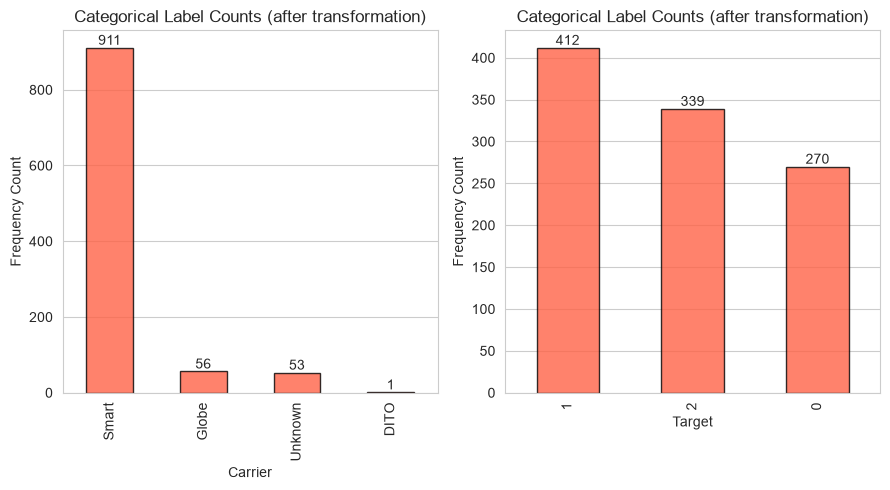

In [76]:
categoricals = ['carrier', 'target']

fig, ax = plt.subplots(1, 2, figsize=(9, 5))

sns.set_style('whitegrid')
for i, cats in enumerate(categoricals):
    counts = clean[cats].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', alpha=0.8, ax=ax[i], edgecolor='black', color='tomato')
    ax[i].set_ylabel('Frequency Count')
    ax[i].set_xlabel(f"{cats.title()}")
    ax[i].set_title('Categorical Label Counts (after transformation)')
    ax[i].bar_label(ax[i].containers[0])
    ax[i].grid(axis='x')
plt.tight_layout()

Text(0.5, 1.0, 'Scam Messages by Months')

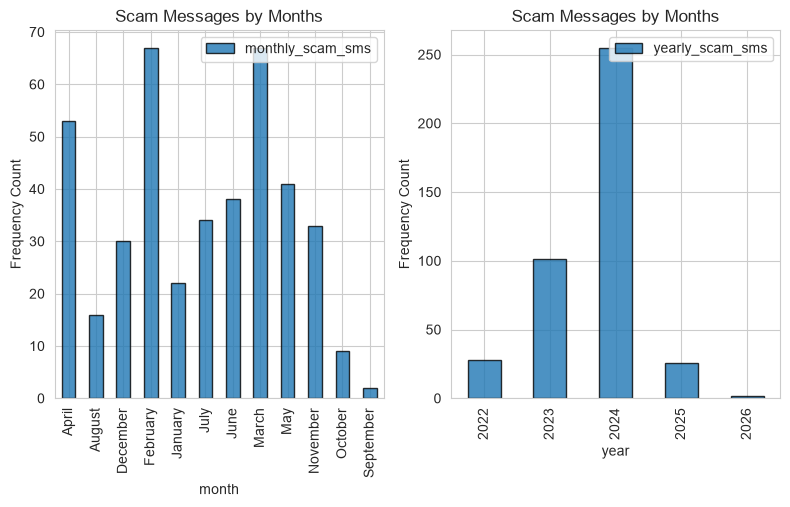

In [77]:
monthly_smishing = clean[clean['target'] == 1]
monthly_smishing = monthly_smishing.groupby('month').agg(
    monthly_scam_sms = ('target', 'count')
)

yearly_smishing = clean[clean['target'] == 1]
yearly_smishing = yearly_smishing.groupby('year').agg(
    yearly_scam_sms = ('target', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

monthly_smishing.plot(kind='bar', edgecolor='black', alpha=.8, ax=axes[0])
yearly_smishing.plot(kind='bar', edgecolor='black', alpha=.8, ax=axes[1])
axes[0].set_ylabel('Frequency Count')
axes[1].set_ylabel('Frequency Count')
plt.tight_layout()
axes[0].set_title('Scam Messages by Months')
axes[1].set_title('Scam Messages by Months')

In [78]:
monthly_smishing.sort_values('monthly_scam_sms', ascending=False)

,monthly_scam_sms
month,
February,67
March,67
April,53
May,41
June,38
July,34
November,33
December,30
January,22


In [79]:
yearly_smishing.sort_values('yearly_scam_sms', ascending=False)

,yearly_scam_sms
year,
2024,255
2023,101
2022,28
2025,26
2026,2


Text(0, 0.5, 'Frequency Count')

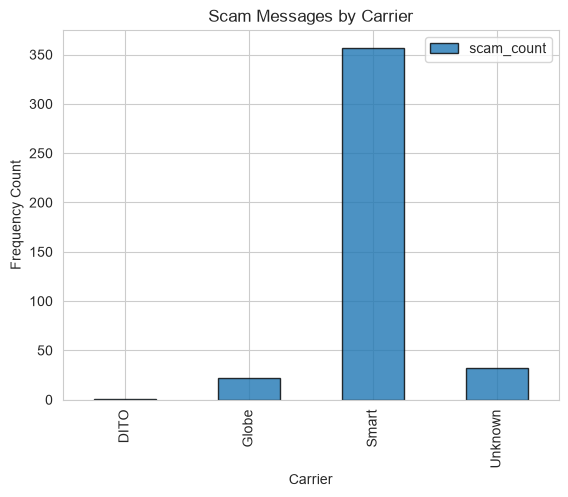

In [80]:
carrier_by_scam = clean[clean['target'] == 1]
carrier_by_scam = carrier_by_scam.groupby('carrier').agg(
    scam_count = ('target', 'count')
)

carrier_by_scam.plot(kind='bar', alpha=0.8, edgecolor='black')
plt.title('Scam Messages by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Frequency Count')

## Feature Significance

<Axes: >

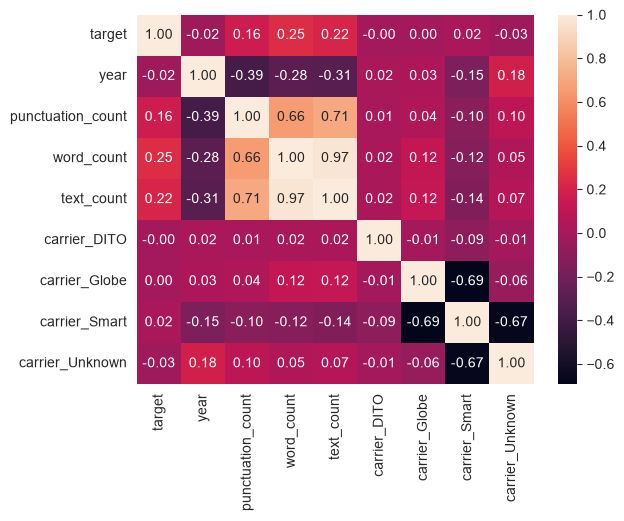

In [81]:
# one hot encode carriers
clean = pd.get_dummies(clean, columns=['carrier'], dtype='int')

# corr heatmap
sns.heatmap(clean.corr(numeric_only=True), annot=True, fmt='.2f')

Text(0, 0.5, 'Features')

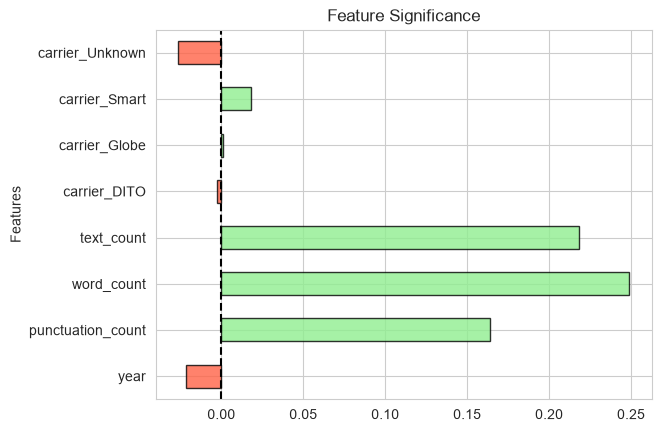

In [82]:
feature_sig = clean.corr(numeric_only=True)['target'].drop('target', axis=0)

color_lbls = ['lightgreen' if corr > 0 else 'tomato' for corr in feature_sig]
feature_sig.plot(kind='barh', color=color_lbls, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Feature Significance')
plt.ylabel('Features')

## Feature Engineering (Text)

In [83]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# removing stopwords: words that has little to no weight

TAGALOG_STOPWORDS = {
    'ang','mga','ng','sa','na','ay','at','ito','iyon','yan','yun','si','ni','kay',
    'ako','ikaw','ka','siya','kami','tayo','kayo','sila','ko','mo','niya','namin',
    'natin','ninyo','nila','akin','iyo','kanya','amin','atin','inyo','kanila',
    'iyan','doon','dito','diyan','paano','bakit','saan','kailan','sino',
    'ano','alin','ba','po','opo','oo','hindi','wag','huwag','lang','din','rin',
    'pa','nga','naman','kung','kapag','dahil','kasi','para','upang','pero',
    'ngunit','o','may','meron','wala','yung','yong','nung','noon',
    'ganito','ganyan','ganoon','sana','daw','raw','muna','ulit','uli','talaga'
}

STOPWORDS = set(stopwords.words('english')) | TAGALOG_STOPWORDS

def remove_stopwords(text: str) -> str:
    tokens = [t for t in str(text).split() if t not in STOPWORDS and t != '']
    return ' '.join(tokens)

clean['text_transformed'] = clean['text_transformed'].apply(remove_stopwords)
clean['dedup_group_id'] = clean['text_transformed'].factorize()[0]
clean = clean.drop(['text'], axis=1)

# reorganize columns
clean = clean[['date', 'year', 'month', 'punctuation_count',
               'word_count', 'text_count', 'carrier_Smart', 'carrier_Globe', 'carrier_DITO',
               'carrier_Unknown', 'dedup_group_id', 'text_transformed','target']]
clean.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LEI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,date,year,month,punctuation_count,word_count,text_count,carrier_Smart,carrier_Globe,carrier_DITO,carrier_Unknown,dedup_group_id,text_transformed,target
0,2026-07-01 09:13:32.668,2026,July,8,20,120,0,0,0,1,0,login free spin marami nakakuha moneytoken sus...,2
1,2026-04-23 01:01:22.884,2026,April,4,27,148,1,0,0,0,1,condo across ateneo torre lorenzo studio units...,2
2,2026-03-27 06:23:44.260,2026,March,6,32,164,1,0,0,0,2,papalduhin kita moneytoken ngayon basta bahala...,1
3,2026-02-17 10:25:35.838,2026,February,11,35,182,1,0,0,0,3,boss panalunin kita pinata win moneytoken haba...,1
4,2026-01-19 16:13:33.766,2026,January,5,19,106,1,0,0,0,4,nagsisimula saya panalo moneytoken free moneyt...,2


## Load the Transformed Dataset

In [84]:
clean.to_csv('../data/processed/sms_data_cleaned.csv', index=False)